In [1]:
import os
from IPython.display import Image, display



Problem Statement:

Your task is to develop an algorithm that parses the relevant information out of that page into **structured, machine-readable output**.

A heads-up on why this is hard: 
standard OCR and off-the-shelf vision-language models tend to do poorly on pages like this 
- messy handwriting, 
- scientific shorthand,
-  and hand-drawn chemical structures.

Getting those right is the point of the exercise.

We'll evaluate your submission on four levels, in roughly increasing order of difficulty:
1. Text — can your algorithm accurately extract the handwritten plain text (the written notes, procedures, and tables)?
2. Special symbols — can it correctly capture scientific notation and symbols that typically get mangled (e.g., °C, λ, θ, units, sub/superscripts)?
3. Chemistry — can it extract the chemical content, including the hand-drawn molecular structures, formulas, reagents, and concentrations?
4. Experiment — can it figure out what was actually happening in the experiment: the goal, the conditions, the procedure, and the results?

Aim as far up this list as you can — partial solutions are still valuable, so show us how far you get. Where something is ambiguous, make reasonable assumptions and note them in your submission.

To submit, please send us two things by Thursday at 3:00 PM ET:
A ~2-minute video demonstrating your algorithm's performance, and
A link to the GitHub repository containing your code.



## Prototype idea: 

- use a document YOLO to parse out regions of the scientific writing, figure out if it's a table, equation, unknown, whatever. 
- From each of the different regions, tell what kind of text it is, if it's unrecognizable then feed it into llm / small vlm
- Stitch the text together, send to llm for inference.


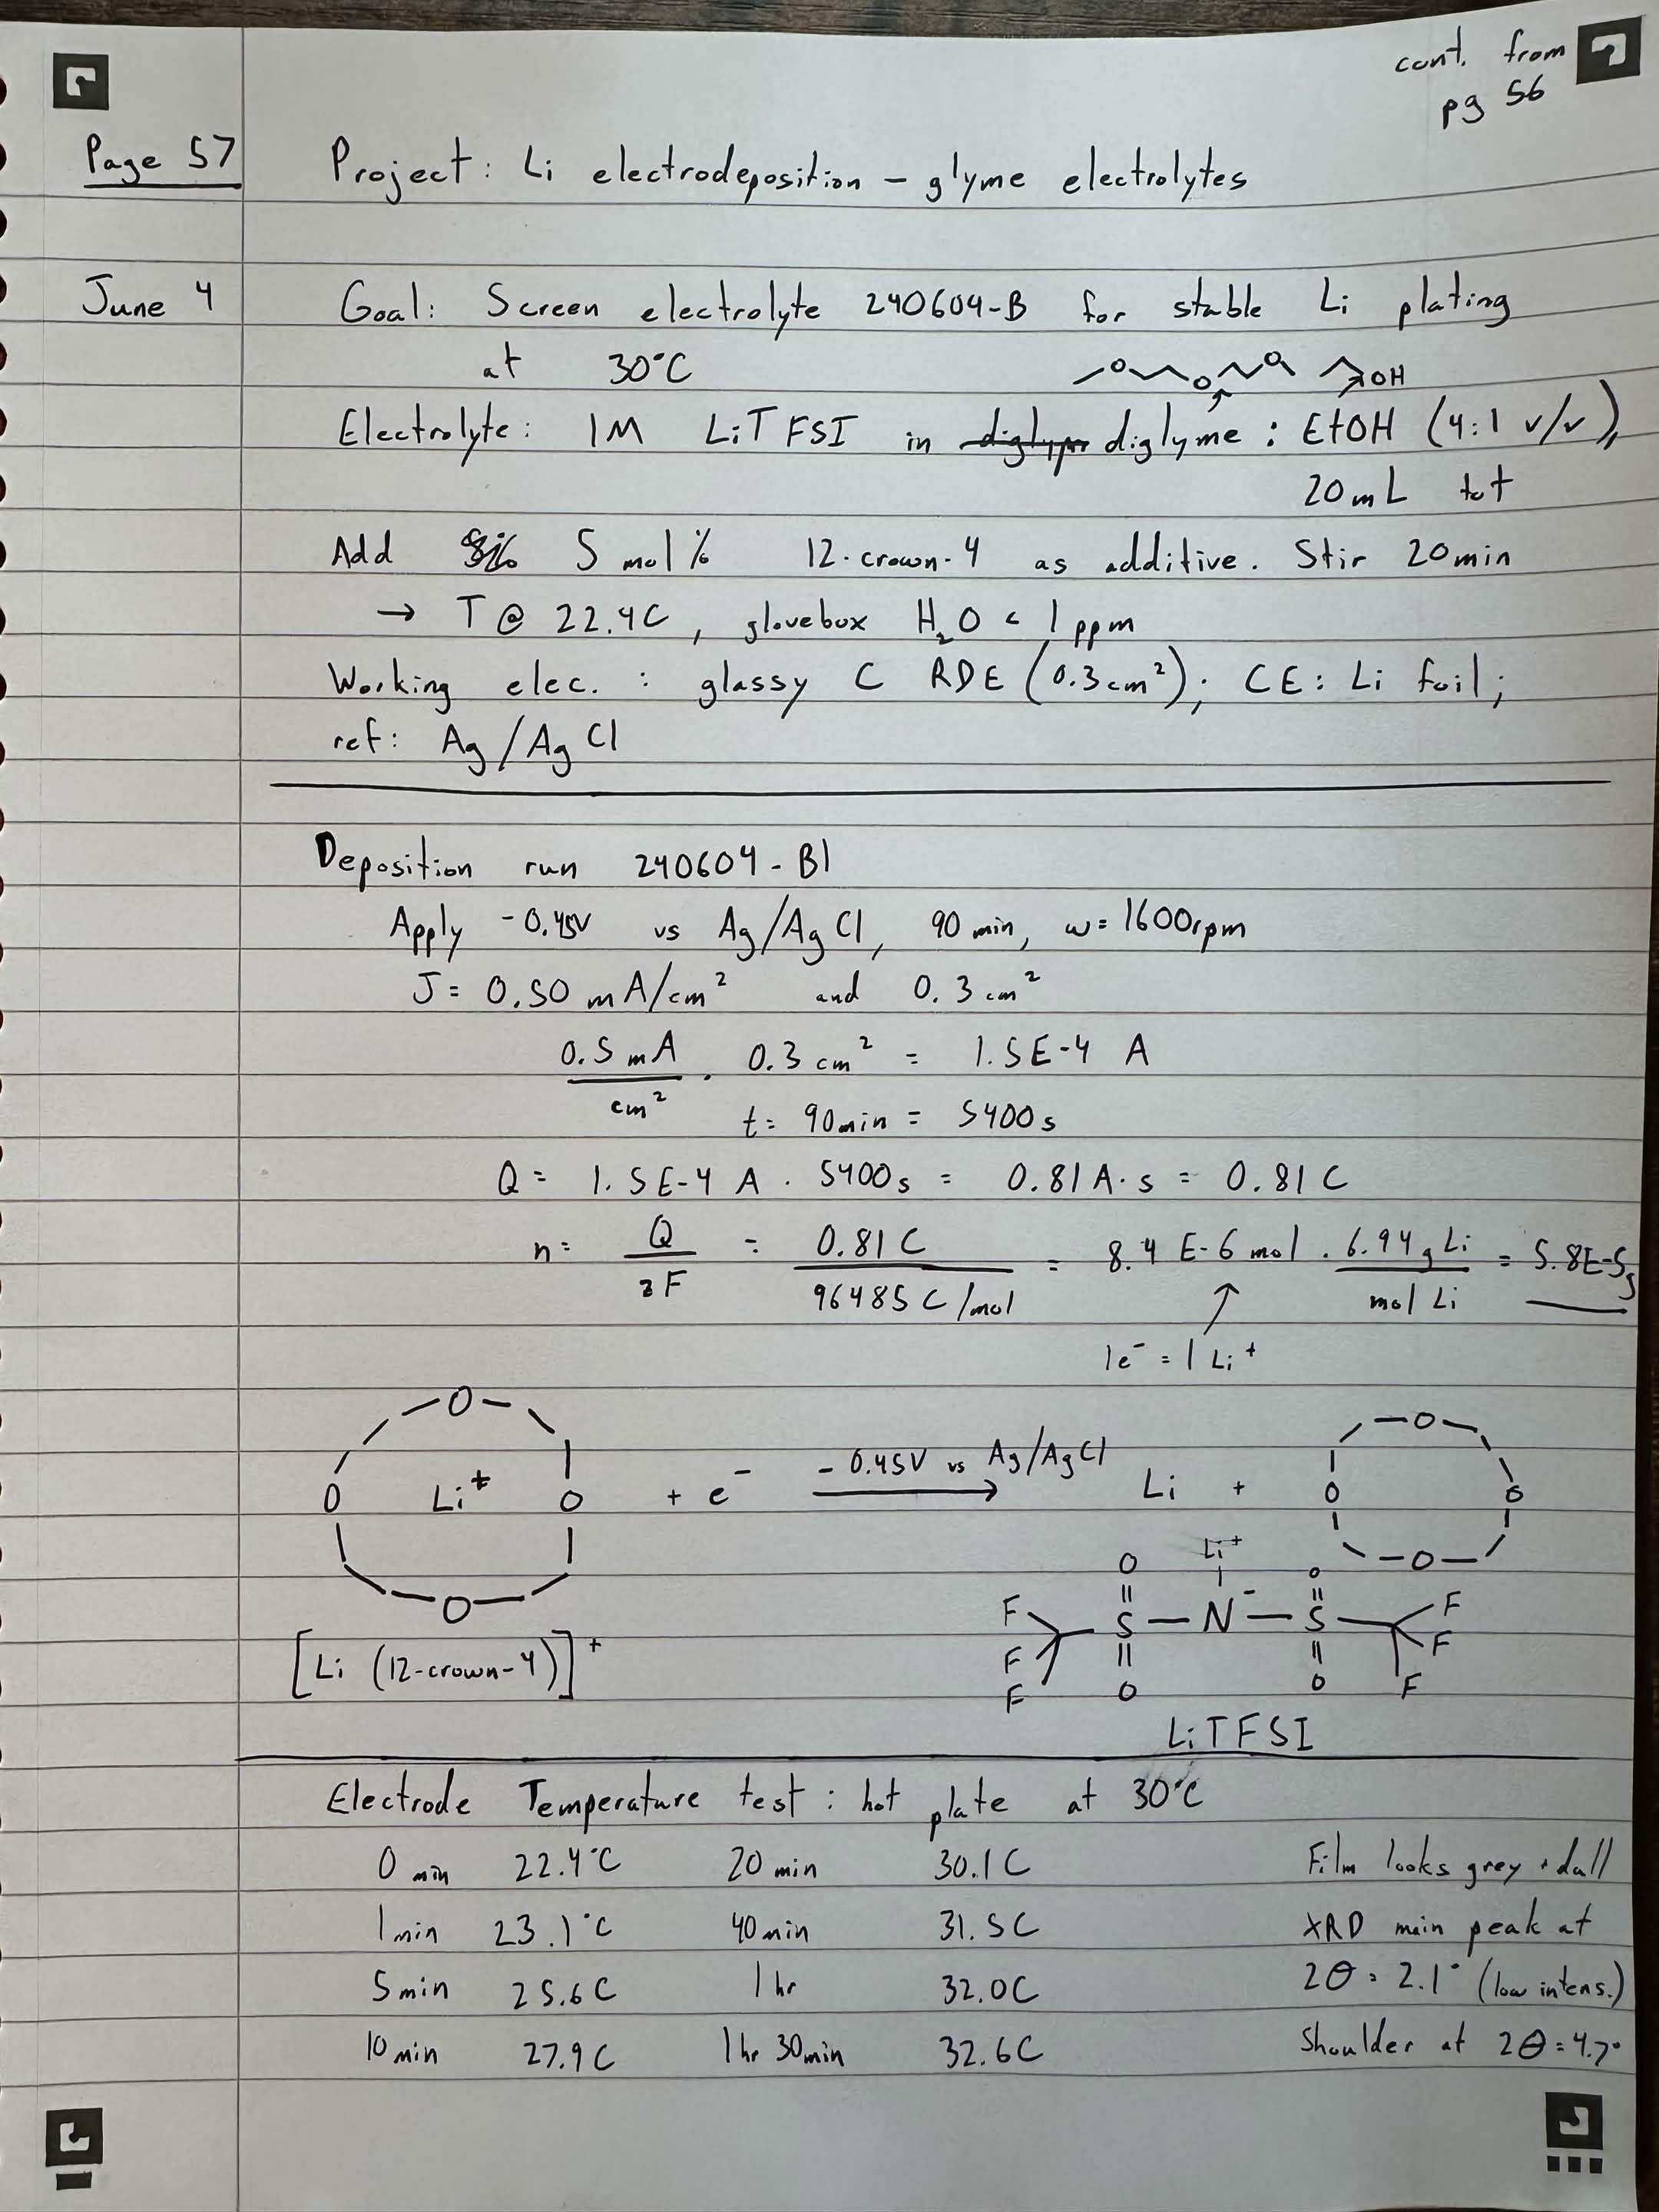

In [2]:
img_path = '/Users/ehuang32/Downloads/Example Lab Notebook Page.jpg'
# Using the variable you already defined
display(Image(filename=img_path,width=500))

In [3]:
# import cv2
# from huggingface_hub import hf_hub_download
# from doclayout_yolo import YOLOv10

# # 1. Download the pre-trained DocLayout-YOLO weights from Hugging Face
# model_path = hf_hub_download(
#     repo_id="juliozhao/DocLayout-YOLO-D4LA-Docsynth300K_pretrained", 
#     filename="doclayout_yolo_d4la_imgsz1600_docsynth_pretrain.pt"
# )
# # 2. Initialize the YOLOv10 layout model
# model = YOLOv10(model_path)

# # 3. Predict the layout regions on your lab notebook page
# results = model.predict(
#     img_path,
#     imgsz=1024,
#     conf=0.25,  # Adjust confidence as needed
#     device="cpu"  # Change to "cuda:0" or "mps" if you have GPU acceleration
# )

# # 4. View the layout bounding boxes overlaid on your image
# annotated_frame = results[0].plot(pil=True, line_width=3, font_size=14)
# cv2.imwrite('/Users/ehuang32/Downloads/parsed_layout.jpg', annotated_frame)

# # Quick look in your notebook
# from IPython.display import Image
# Image(filename='/Users/ehuang32/Downloads/parsed_layout.jpg', width=500)

In [4]:
# import numpy as np

# # Load original image for cropping
# img = cv2.imread(img_path)
# h, w, _ = img.shape
# names = model.names

# # 1. Pull the bounding boxes directly from your new granular results
# boxes = results[0].boxes.xyxy.cpu().numpy()
# scores = results[0].boxes.conf.cpu().numpy()
# clss = results[0].boxes.cls.cpu().numpy()

# # 2. Sort top-to-bottom, left-to-right using a smaller row margin for handwriting lines
# def get_granular_sorting_key(item, line_margin=15):
#     x1, y1, x2, y2 = item[0]
#     return (int(y1) // line_margin), x1

# all_items = list(zip(boxes, scores, clss))
# sorted_items = sorted(all_items, key=get_granular_sorting_key)

# extracted_regions = []

# for idx, (box, conf, cls_id) in enumerate(sorted_items):
#     label = names[int(cls_id)]
#     x1, y1, x2, y2 = map(int, box)
    
#     # Clip boundaries to image dimensions
#     x1, y1 = max(0, x1), max(0, y1)
#     x2, y2 = min(w, x2), min(h, y2)
    
#     if (x2 - x1) <= 0 or (y2 - y1) <= 0:
#         continue
        
#     # Crop the snippet
#     cropped_img = img[y1:y2, x1:x2]
    
#     crop_save_path = f"/Users/ehuang32/Downloads/crop_{idx}_{label}.jpg"
#     cv2.imwrite(crop_save_path, cropped_img)
    
#     extracted_regions.append({
#         "index": idx,
#         "label": label,
#         "confidence": float(conf),
#         "box": [x1, y1, x2, y2],
#         "crop_path": crop_save_path
#     })

# print(f"Successfully extracted {len(extracted_regions)} detailed layout regions!")

In [7]:
import cv2
import numpy as np
from paddleocr import PaddleOCRVL

# 1. Initialize the correct Vision-Language pipeline version
print("🚀 Initializing PaddleOCR-VL-1.5 multimodal engine...")
pipeline = PaddleOCRVL(pipeline_version="v1.5")

# 2. Run inference using the dedicated VLM predict API
# This bypasses the old pipeline wrapper entirely

Creating model: ('PP-DocLayoutV3', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ehuang32/.paddlex/official_models/PP-DocLayoutV3`.


🚀 Initializing PaddleOCR-VL-1.5 multimodal engine...


Creating model: ('PaddleOCR-VL-1.5-0.9B', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ehuang32/.paddlex/official_models/PaddleOCR-VL-1.5`.
Bucketed engine_config has no entry for resolved engine 'paddle_dynamic'; using an empty config for that engine.
Loading configuration file /Users/ehuang32/.paddlex/official_models/PaddleOCR-VL-1.5/config.json
Loading weights file /Users/ehuang32/.paddlex/official_models/PaddleOCR-VL-1.5/model.safetensors
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 

In [8]:
print("📸 Analyzing lab page via end-to-end VLM...")
output = pipeline.predict(img_path)

# 3. Process the multi-task vision-language outputs
paddle_regions = []
print("\n--- Extracted Document Structure ---")

for res in output:
    # Handle the structured response fields returned by the VL model
    text = res.get("text", "")
    label = res.get("label", "text")  # table, formula, chart, seal, text
    box = res.get("bbox", [0, 0, 0, 0])
    conf = res.get("confidence", 1.0)
    
    paddle_regions.append({
        "text": text,
        "label": label,
        "confidence": conf,
        "bbox": box
    })
    
    print(f"[{label.upper()}][{conf:.2f}] -> {text}")

print(f"\n✅ PaddleOCR-VL successfully parsed {len(paddle_regions)} semantic document blocks!")

📸 Analyzing lab page via end-to-end VLM...

--- Extracted Document Structure ---
[TEXT][1.00] -> 

✅ PaddleOCR-VL successfully parsed 1 semantic document blocks!


In [6]:
# Sort blocks top-to-bottom based on their vertical positioning
paddle_regions_sorted = sorted(paddle_regions, key=lambda x: x["bbox"][1])

stitched_text_blocks = []
current_line_y = -1
current_line_text = []

# Group words that sit closely on the same horizontal plane (within 15 pixels)
for region in paddle_regions_sorted:
    ymin = region["bbox"][1]
    text = region["text"]
    
    if current_line_y == -1:
        current_line_y = ymin
        current_line_text.append(text)
    elif abs(ymin - current_line_y) < 15:
        current_line_text.append(text)
    else:
        stitched_text_blocks.append(" ".join(current_line_text))
        current_line_y = ymin
        current_line_text = [text]

if current_line_text:
    stitched_text_blocks.append(" ".join(current_line_text))

final_stitched_context = "\n".join(stitched_text_blocks)
print("\n--- Final Structured Stitched Text Context ---")
print(final_stitched_context)


--- Final Structured Stitched Text Context ---

